In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class IdentityBlock(nn.Module):
    def __init__(self, filters, se=False, SE_Block=None, stride=1):
        super().__init__()
        
        self.f1, self.f2, self.f3 = filters
        self.stride = stride
        self.se = se
        
        self.shortcut = nn.Identity()
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(self.f1, self.f2, kernel_size=1, stride=self.stride),
            nn.BatchNorm2d(self.f2),
            nn.ReLU(),
            nn.Conv2d(self.f2, self.f2, kernel_size=3, stride=self.stride, padding=1),
            nn.BatchNorm2d(self.f2),
            nn.ReLU(),
            nn.Conv2d(self.f2, self.f3, kernel_size=1, stride=self.stride),
            nn.BatchNorm2d(self.f3),
            nn.ReLU()
        )
        
        # squeeze excitation block 
        if self.se:
            self.se_block = SE_Block(self.f3)
            
        else:
            self.se_block = nn.Identity()
        
    def forward(self, x):
        #print(x.shape, 'x without conv')
        out = self.conv_block(x)
        out = self.se_block(out)
        #print(out.shape, 'this is out')
        #print(x.shape, 'this is x')
        out += self.shortcut(x)
        out = F.relu(out)
        
        return out
    
class ConvBlock(nn.Module):
    def __init__(self, filters, version, se=False, SE_Block=None, stride=2, padding=0):
        super().__init__()
        
        self.f1, self.f2, self.f3 = filters
        self.stride = stride
        self.padding = padding
        self.version = version
        self.se = se
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(self.f1, self.f2, kernel_size=1, stride=self.stride),
            nn.BatchNorm2d(self.f2),
            nn.ReLU(),
            nn.Conv2d(self.f2, self.f2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(self.f2),
            nn.ReLU(),
            nn.Conv2d(self.f2, self.f3, kernel_size=1, stride=1),
            nn.BatchNorm2d(self.f3),
            nn.ReLU()
        )
        
        if self.version == 'A':
            self.shortcut = nn.Sequential(
                    nn.AvgPool2d(kernel_size=3, stride=self.stride, padding=self.padding),
                    nn.Conv2d(self.f1, self.f3, kernel_size=1, stride=1),
                    nn.BatchNorm2d(self.f3)
            )
            
        elif self.version == 'B':
            self.shortcut = nn.Sequential(
                    nn.Conv2d(self.f1, self.f3, kernel_size=1, stride=self.stride),
                    nn.BatchNorm2d(self.f3)
            )
        
        # squeeze excitation block 
        if self.se:
            self.se_block = SE_Block(self.f3)
            
        else:
            self.se_block = nn.Identity()
            
            
    def forward(self, x):
        #print(x.shape, 'x without conv')    
        out = self.conv_block(x)
        out = self.se_block(out)
        #print(out.shape, 'this is out')
        #print(self.shortcut(x).shape, 'this is x ')
        out += self.shortcut(x)
        out = F.relu(out)
            
        return out
    
class SE_Block(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1) # 1 x 1 x C
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // r),
            nn.ReLU(),
            nn.Linear(channels // r, channels),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        N, C, _, _ = x.shape
        out = self.squeeze(x)
        #print(out.shape, 'after squeeze')
        out = out.view(-1, C)
        #print(out.shape, 'after view')
        out = self.excitation(out)
        #print(out.shape, 'after excitation')
        out = out.view(N, C, 1, 1)
        out = out * x
        
        return out
    
class ResNet50(nn.Module):
    def __init__(self, conv_block, identity_block, version, se=False, SE_Block=None, num_classes=10):
        super().__init__()
        self.version = version
        self.se = se
        
        # zero layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=4)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=3, stride=2)
        
        # first layer
        self.conv_block1 = conv_block([64, 64, 256], self.version, se=self.se, SE_Block=SE_Block, stride=1, padding=1)
        self.identity_block1 = identity_block([256, 64, 256], se=self.se, SE_Block=SE_Block)
        self.identity_block2 = identity_block([256, 64, 256], se=self.se, SE_Block=SE_Block)
        
        # second layer
        self.conv_block2 = conv_block([256, 128, 512], self.version, se=self.se, SE_Block=SE_Block, stride=2, padding=1)
        self.identity_block3 = identity_block([512, 128, 512], se=self.se, SE_Block=SE_Block)
        self.identity_block4 = identity_block([512, 128, 512], se=self.se, SE_Block=SE_Block)
        self.identity_block5 = identity_block([512, 128, 512], se=self.se, SE_Block=SE_Block)
        
        # third layer
        self.conv_block3 = conv_block([512, 256, 1024], self.version, se=self.se, SE_Block=SE_Block, stride=2, padding=1)
        self.identity_block6 = identity_block([1024, 256, 1024], se=self.se, SE_Block=SE_Block)
        self.identity_block7 = identity_block([1024, 256, 1024], se=self.se, SE_Block=SE_Block)
        self.identity_block8 = identity_block([1024, 256, 1024], se=self.se, SE_Block=SE_Block)
        self.identity_block9 = identity_block([1024, 256, 1024], se=self.se, SE_Block=SE_Block)
        self.identity_block10 = identity_block([1024, 256, 1024], se=self.se, SE_Block=SE_Block)
        
        # fourth layer 
        self.conv_block4 = conv_block([1024, 512, 2048], self.version, se=self.se, SE_Block=SE_Block, stride=2, padding=1)
        self.identity_block11 = identity_block([2048, 512, 2048], se=self.se, SE_Block=SE_Block)
        self.identity_block12 = identity_block([2048, 512, 2048], se=self.se, SE_Block=SE_Block)
        
        # linear layer
        self.linear = nn.Linear(2048, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.identity_block2(self.identity_block1(self.conv_block1(x)))
        
        x = self.identity_block5(self.identity_block4(self.identity_block3(self.conv_block2(x))))
        
        x = self.identity_block10(self.identity_block9(self.identity_block8(self.identity_block7(self.identity_block6(self.conv_block3(x))))))
        
        x = self.identity_block12(self.identity_block11(self.conv_block4(x)))
        
        x = F.avg_pool2d(x, x.shape[3])
        #print(x.shape, 'final shape')
        x = x.view(x.shape[0], -1)
        #print(x.shape, 'prelinear shape')
        x = self.linear(x)
        
        return x

In [34]:
input = torch.randn(1, 64, 8, 9)
m = nn.AdaptiveAvgPool2d(1)
n = nn.AvgPool2d(7)

In [35]:
m(input).shape, n(input).shape

(torch.Size([1, 64, 1, 1]), torch.Size([1, 64, 1, 1]))

In [36]:
input = torch.randn(1, 64, 8, 9)

In [43]:
output = SE_resnet(64, r=3)(input)

In [44]:
output.shape

torch.Size([1, 64, 8, 9])

In [2]:
%env CUDA_VISIBLE_DEVICES = 7

env: CUDA_VISIBLE_DEVICES=7


In [20]:
from fetch_dataset_and_processing import find_train_val_files, find_test_files, ImageNet
from train_loop import train
from inference import predict, predict_one_sample, make_predictions
from visualizing import imshow, plot_train_set, plot_results

from resnet50 import IdentityBlock, ConvBlock, ResNet50
from resnet18_cnn import ResBlock, ResNet18

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [1]:
! nvidia-smi

Fri Feb  3 08:59:55 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 520.56.06    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:1A:00.0 Off |                  N/A |
| 27%   31C    P0    47W / 260W |      0MiB / 11264MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:1B:00.0 Off |                  N/A |
| 25%   

In [5]:
device = 'cuda:0'

In [6]:
train_val_files, train_val_labels = find_train_val_files()
test_files, test_labels = find_test_files()

In [7]:
len(train_val_files), len(test_files)

(9103, 3791)

In [8]:
train_set, val_set, tr_labels, val_labels = train_test_split(train_val_files, train_val_labels, test_size=0.2, \
                                          stratify=train_val_labels)

In [9]:
train_dataset = ImageNet(train_set, tr_labels, 'train')
val_dataset = ImageNet(val_set, val_labels, 'val')
test_dataset = ImageNet(test_files, test_labels, 'test')

In [10]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [11]:
resnet = ResNet50(ConvBlock, IdentityBlock, 'B', se=True, SE_Block=SE_Block).to(device)

In [41]:
sample = next(iter(train_loader))[0]

In [42]:
resnet(sample)

tensor([[ 0.5714, -0.7469,  0.8916, -0.0578, -0.1231,  0.6522, -0.7131, -0.6460,
          0.3527,  0.3309],
        [ 0.5310, -0.4913,  0.7167, -0.1450, -0.1494,  0.4068, -0.6940, -0.4388,
          0.3650,  0.3739],
        [ 0.8347, -0.8616,  1.0353, -0.1384, -0.2091,  0.6242, -0.8637, -0.7137,
          0.4622,  0.2872],
        [ 0.5329, -0.5213,  0.7987, -0.2099, -0.3395,  0.4238, -0.7492, -0.3401,
          0.4318,  0.3683],
        [ 0.6851, -0.8687,  0.9610, -0.1115, -0.3289,  0.6661, -0.8689, -0.7245,
          0.4225,  0.1221],
        [ 0.6005, -0.7157,  0.9865, -0.1559, -0.2409,  0.6567, -0.8137, -0.6603,
          0.4574,  0.2508],
        [ 0.6527, -0.7360,  0.9593, -0.1663, -0.2628,  0.6014, -0.8753, -0.6114,
          0.5119,  0.3083],
        [ 0.6887, -1.2226,  0.8762, -0.1357, -0.3679,  0.5681, -1.0133, -0.7885,
          0.6295,  0.1841],
        [ 0.7459, -1.0063,  0.8784, -0.0844, -0.2003,  0.6653, -1.0742, -1.0886,
          0.5034,  0.1657],
        [ 0.9097, -

In [12]:
epochs = 20
opt = torch.optim.Adam(resnet.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
path = 'ResNet_exp/Resnet_50_SE.pth'
name = 'ResNet_exp/resnet_50_SE'

In [13]:
losses, metrics = train(resnet, opt, loss_fn, epochs, train_loader, val_loader, name, path)

Epoch 0/19:


train iter:: 100%|██████████| 911/911 [02:51<00:00,  5.32it/s]


train Loss: 1.7290
train Accuracy: 0.4138


val iter:: 100%|██████████| 228/228 [00:15<00:00, 14.60it/s]


val Loss: 2.1039
val Accuracy: 0.3992
Epoch 1/19:


...

val Loss: 0.7414
val Accuracy: 0.7620
Epoch 19/19:


train iter:: 100%|██████████| 911/911 [02:48<00:00,  5.39it/s]


train Loss: 0.3138
train Accuracy: 0.9240


val iter:: 100%|██████████| 228/228 [00:15<00:00, 14.38it/s]


val Loss: 0.7414
val Accuracy: 0.7620


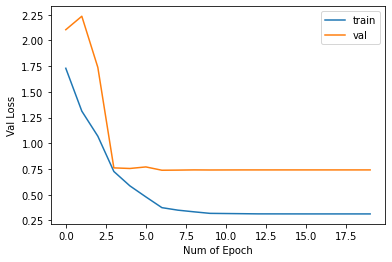

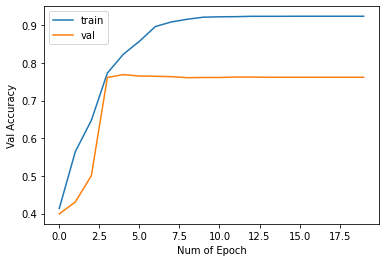

In [17]:
plt.plot(losses['train'], label='train')
plt.plot(losses['val'], label='val')
plt.legend()
plt.ylabel('Val Loss')
plt.xlabel('Num of Epoch')
plt.show()


plt.plot(metrics['train'], label='train')
plt.plot(metrics['val'], label='val')
plt.ylabel('Val Accuracy')
plt.xlabel('Num of Epoch')
plt.legend()
plt.show()

### Inference

In [10]:
resnet = ResNet50(ConvBlock, IdentityBlock, 'B').to(device)
path = 'ResNet_exp/Resnet_50 (without).pth'
resnet.load_state_dict(torch.load(path))

<All keys matched successfully>

In [18]:
idxs = range(len(test_dataset)) 
imgs = [test_dataset[id][0].unsqueeze(0) for id in idxs]
actual_labels = [test_dataset[id][1] for id in idxs]

In [19]:
predictions = make_predictions(resnet, imgs)
acc = accuracy_score(predictions, actual_labels)

print(f'The accuracy on the test set of ResNet50 is {round(acc, 4)}')

The accuracy on the test set of ResNet50 is 0.7584
